In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import coremltools as ct
from skl2onnx import to_onnx

df = pd.read_csv("./simple_housing.csv")

In [37]:
# Define features and target
Features = df[["SquareFootage"]]
Target = df["Price"]

X = Features
y = Target

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55 entries, 0 to 54
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   SquareFootage  55 non-null     int64
 1   Bedrooms       55 non-null     int64
 2   Price          55 non-null     int64
dtypes: int64(3)
memory usage: 1.4 KB


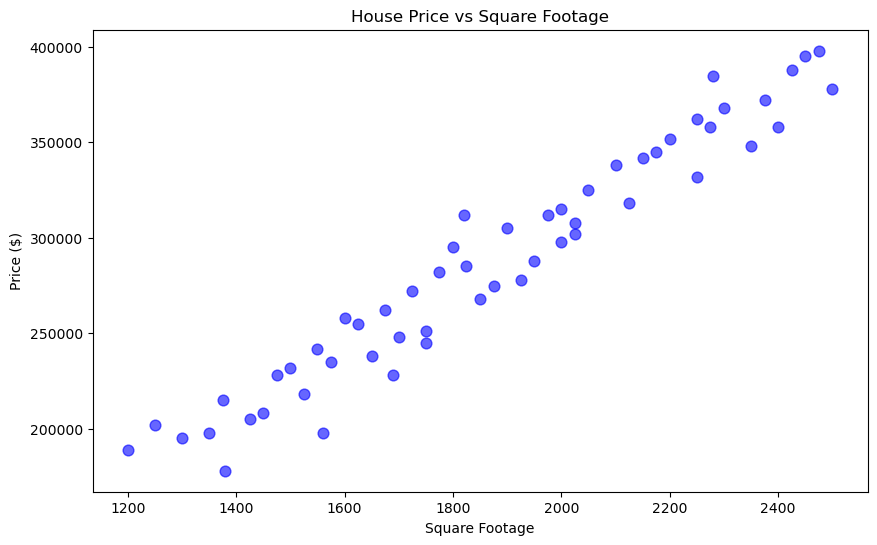

In [39]:
# Step 4B
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', alpha=0.6, s=60)
plt.xlabel('Square Footage')
plt.ylabel('Price ($)')
plt.title('House Price vs Square Footage')
plt.show()

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape

(44, 1)

In [41]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

/Users/davidfekke/Documents/python/projects/mynotebooks/lesson-17/.pixi/envs/default/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


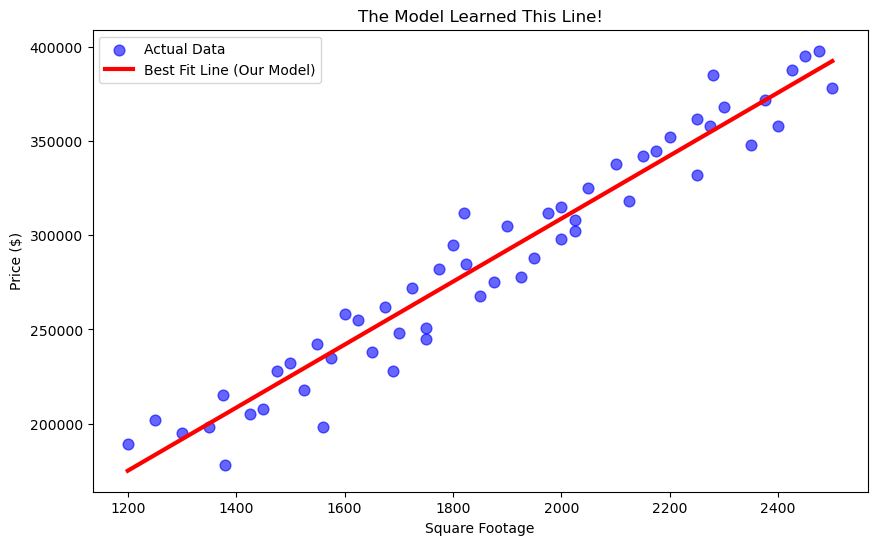

In [42]:
plt.figure(figsize=(10, 6))

# Scatter plot of all data points
plt.scatter(df['SquareFootage'], df['Price'], color='blue', alpha=0.6, s=60, label='Actual Data')

# Create the regression line
X_line = np.linspace(df['SquareFootage'].min(), df['SquareFootage'].max(), 100).reshape(-1, 1)
y_line = model.predict(X_line)

# Plot the line
plt.plot(X_line, y_line, color='red', linewidth=3, label='Best Fit Line (Our Model)')

plt.xlabel('Square Footage')
plt.ylabel('Price ($)')
plt.title('The Model Learned This Line!')
plt.legend()
plt.show()

In [43]:

model_prediction = model.predict([[2400]])
print(f"${round(model_prediction[0], 2)}\n")

$375767.98



/Users/davidfekke/Documents/python/projects/mynotebooks/lesson-17/.pixi/envs/default/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [44]:
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
r2

0.921126350075431

In [45]:
coreml_model = ct.converters.sklearn.convert(
    model,
    input_features=["squarefootage"],
    output_feature_names="price"
)

coreml_model.save('HousePricer.mlmodel')

In [46]:
onx = to_onnx(model, X)
with open("HousePricer.onnx", "wb") as f:
    f.write(onx.SerializeToString())

In [50]:
# Compute the prediction with onnxruntime.
import onnxruntime as rt

sess = rt.InferenceSession("HousePricer.onnx", providers=["CPUExecutionProvider"])
input_name = sess.get_inputs()[0].name
label_name = sess.get_outputs()[0].name
# Get predictions for a single value of 2400 square feet. How can I just pass one value into the model?
pred_onx = sess.run([label_name], {input_name: [[2400]]})
# pred_onx = sess.run([label_name], {input_name: 2400})
print(pred_onx[0][0][0])
print(input_name)
# print(label_name)
# X_test

375767.97
SquareFootage
